In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

X, y = load_diabetes(as_frame=True, scaled=False, return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 3))

MAE : 41.51
RMSE: 53.32
R2  : 0.486


In [2]:
residual = y_test - pred

analisys_df = X_test.copy()
analisys_df["y_true"] = y_test.values
analisys_df["y_pred"] = pred
analisys_df["residual"] = residual
analisys_df["abs_error"] = np.abs(residual)

analisys_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,y_true,y_pred,residual,abs_error
287,61.0,1.0,25.8,90.00,280.0,195.4,55.0,5.0,4.9972,90.0,219.0,138.264436,80.735564,80.735564
211,74.0,1.0,29.8,101.00,171.0,104.8,50.0,3.0,4.3944,86.0,70.0,182.957088,-112.957088,112.957088
72,66.0,2.0,26.0,91.00,264.0,146.6,65.0,4.0,5.5683,87.0,202.0,131.606484,70.393516,70.393516
321,75.0,1.0,31.2,117.67,229.0,138.8,29.0,7.9,5.7236,106.0,230.0,293.231521,-63.231521,63.231521
73,52.0,2.0,24.5,94.00,217.0,149.4,48.0,5.0,4.5850,89.0,111.0,124.252935,-13.252935,13.252935


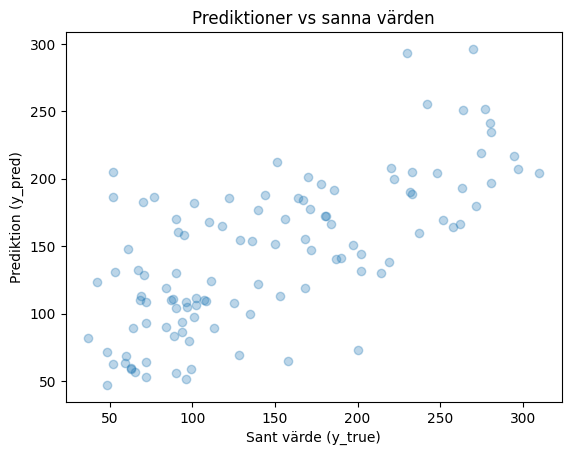

In [4]:
plt.figure()
plt.scatter(analisys_df["y_true"], analisys_df["y_pred"], alpha=0.3)
plt.title("Prediktioner vs sanna värden")
plt.xlabel("Sant värde (y_true)")
plt.ylabel("Prediktion (y_pred)")
plt.show()

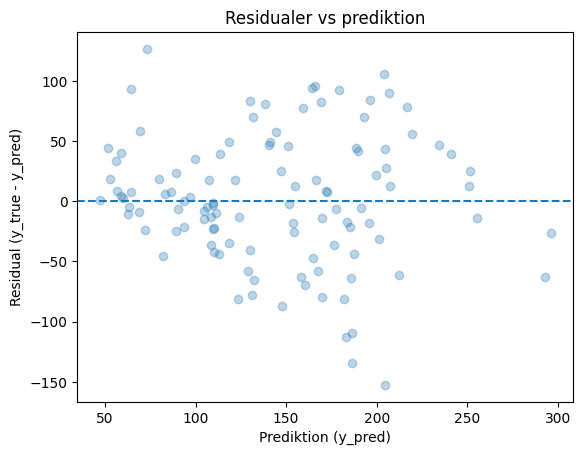

In [5]:
plt.figure()
plt.scatter(analisys_df["y_pred"], analisys_df["residual"], alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("Residualer vs prediktion")
plt.xlabel("Prediktion (y_pred)")
plt.ylabel("Residual (y_true - y_pred)")
plt.show()

In [7]:
worst = analisys_df.sort_values("abs_error", ascending=False).head(10)

worst[["y_true", "y_pred", "residual", "abs_error"]]

,y_true,y_pred,residual,abs_error
56,52.0,204.541048,-152.541048,152.541048
380,52.0,186.313900,-134.313900,134.313900
77,200.0,73.111966,126.888034,126.888034
211,70.0,182.957088,-112.957088,112.957088
209,77.0,186.140867,-109.140867,109.140867
9,310.0,204.291924,105.708076,105.708076
239,262.0,166.217004,95.782996,95.782996
395,258.0,164.090992,93.909008,93.909008
131,158.0,64.517282,93.482718,93.482718
354,272.0,179.330947,92.669053,92.669053


In [8]:
analisys_df["y_bin"] = pd.qcut(analisys_df["y_true"], q=5)

bin_summary = analisys_df.groupby("y_bin").agg(
    mean_abs_error = ("abs_error", "mean"),
    rmse = ("residual", lambda r: np.sqrt(np.mean(r**2))),
    count = ("abs_error", "size")
)

bin_summary

,mean_abs_error,rmse,count
y_bin,,,
"(36.999, 72.0]",44.741435,61.702917,24
"(72.0, 101.0]",34.205908,45.315454,21
"(101.0, 158.0]",31.228759,39.463731,22
"(158.0, 222.0]",37.130308,48.173721,22
"(222.0, 310.0]",59.604405,65.968067,22
